# Mortality Effect Diagnostic Panels

### July 1, 2026
### Emily Zuetell

# Initialization

In [1]:
import os
from dotenv import load_dotenv

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import math
import matplotlib.colors as mcolors


import analysis_utils
import isku_utils
import diagnostic_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

## Load Data

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

In [3]:
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

## Diagnostic Panels

### Climate Data and MMT

In [7]:
# Climate Data by Impact Regoion

forecast = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/2608_forecast_adj_corrected.zarr"
)
forecast_ir = isku_utils.grid_to_ir(forecast, savefile=None)
reanalysis = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/era5_adj_corrected.zarr"
)
reanalysis_ir = isku_utils.grid_to_ir(reanalysis, savefile=None)
# Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/2608_beta_qdm.zarr"
)

projected = effect

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

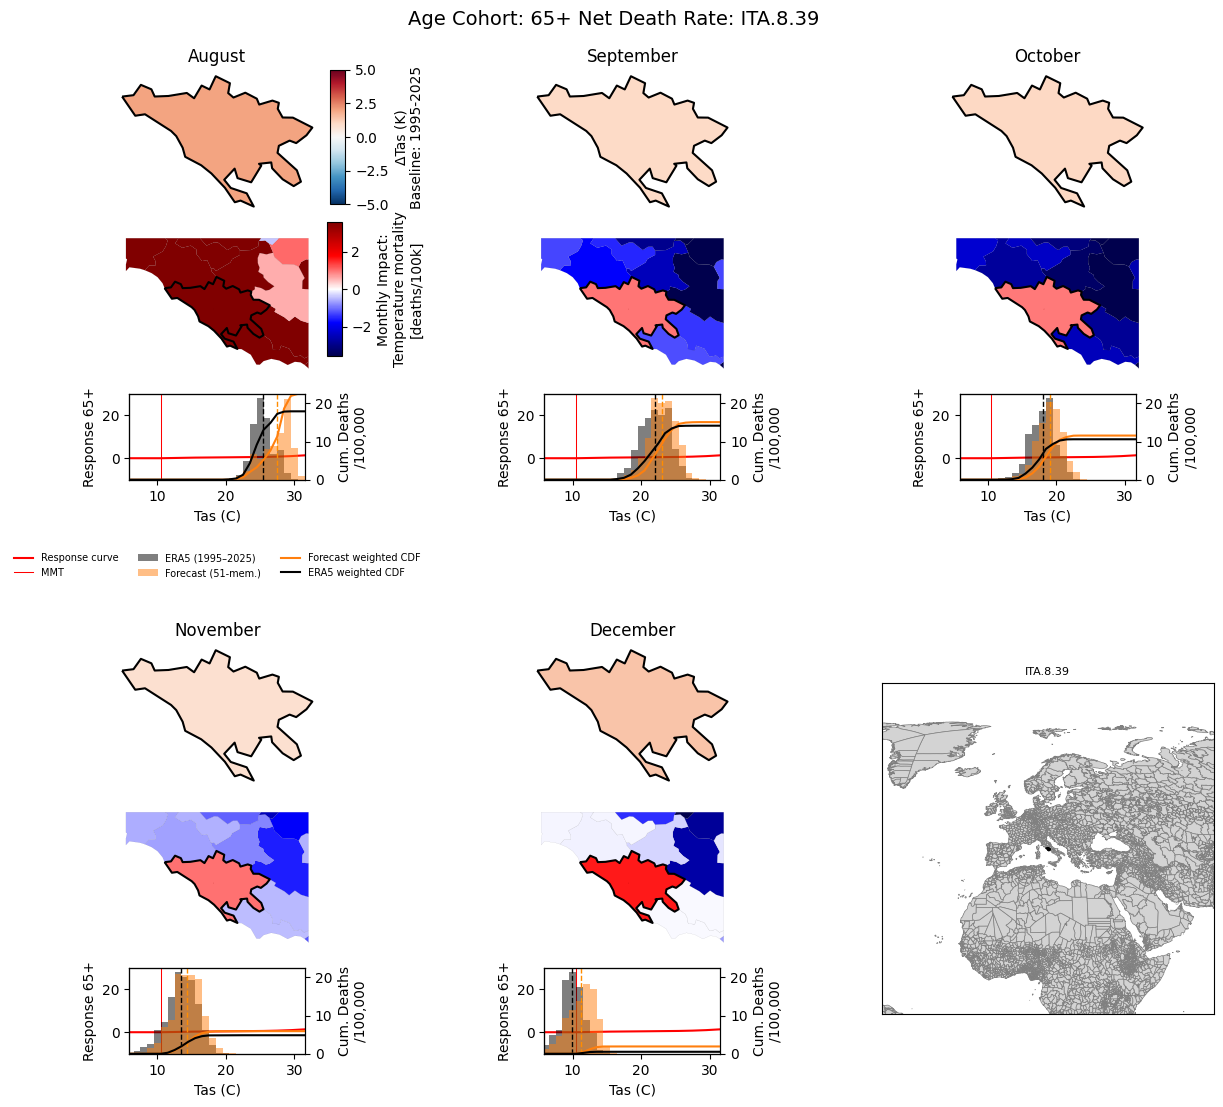

In [12]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

from shapely import box

### Analysis Options ###
rate = True  # Mortality Rate vs Total Deaths
hotonly = False  # Hot-Only Deaths
age_weight = False  # Proportional Age-weighting vs single age group
density_hist = True  # Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

for region_filter in ["ITA.8.39"]:
    # Compute Impact
    regional_sum = analysis_utils.compute_impact(
        projected,
        socioeconomics,
        baseline_period=baseline_period,
        hotonly=hotonly,
        rate=rate,
        age_weight=age_weight,
        chunks={"number": -1, "region": "auto"},
    )

    # Get Months
    months = regional_sum.month.values[1:]
    base_month = months[0]
    lead_by_month = {month: (month - base_month + 1) for month in months}

    # Region bbox
    if region_filter:
        _country = _polygons[_polygons.index == region_filter].to_crs("EPSG:4326")
        minx, miny, maxx, maxy = _country.total_bounds
        bbox_pad = 1
        _country_proj = _country.to_crs("ESRI:54030")
        bminx, bminy, bmaxx, bmaxy = _country_proj.total_bounds
        pad_proj = 50000

    # BBOX Impact Regions
    _polygons_local = (
        _polygons.to_crs("ESRI:54030")
        .clip(
            box(bminx - pad_proj, bminy - pad_proj, bmaxx + pad_proj, bmaxy + pad_proj)
        )
        .reset_index()
    )

    ### Load Climate Data ###
    forecast_local = forecast_ir["tas"].sel(region=[region_filter]) - 273.15
    reanalysis_local = reanalysis_ir["tas"].sel(region=[region_filter]) - 273.15
    tas_anomaly = (
        forecast_local.groupby("time.month").mean().mean(dim="number")
        - reanalysis_local.groupby("time.month").mean()
    )

    combined = np.concat(
        [forecast_local.values.flatten(), reanalysis_local.values.flatten()]
    )
    xmin, xmax = np.percentile(combined, [1, 100])

    # Precompute Impact
    regional_sum_roi = regional_sum.sel(region=region_filter)
    absmax_impact = np.abs(regional_sum_roi).quantile(0.95).values
    norm_impact = mcolors.TwoSlopeNorm(
        vmin=-absmax_impact, vcenter=0, vmax=absmax_impact
    )

    # Compute Cumulative Effect
    cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(
        forecast_local,
        reanalysis_local,
        region_filter,
        months,
        monthly=True,
        hotonly=hotonly,
    )

    # Initialize Figure
    ncols = 3
    n_months = len(months)
    n_pairs = math.ceil(n_months / ncols)
    total_rows = n_pairs * 3

    fig = plt.figure(figsize=(5 * ncols, 6 * n_pairs))
    gs = GridSpec(n_pairs, 1, figure=fig, hspace=0.4)

    top_axes = []
    bot_axes = []
    hist_axes = []

    for pair_row in range(n_pairs):
        inner_gs = GridSpecFromSubplotSpec(
            3,
            ncols,
            subplot_spec=gs[pair_row],
            hspace=0.15,
            wspace=0.25,
            height_ratios=[2, 2, 1.2],
        )
        for col in range(ncols):
            i = pair_row * ncols + col
            if i >= n_months:
                break
            ax_top = fig.add_subplot(inner_gs[0, col])
            ax_bot = fig.add_subplot(inner_gs[1, col])
            hist_gs = GridSpecFromSubplotSpec(
                1, 3, subplot_spec=inner_gs[2, col], width_ratios=[0.2, 0.6, 0.2]
            )
            ax_hist = fig.add_subplot(hist_gs[0, 1])
            top_axes.append(ax_top)
            bot_axes.append(ax_bot)
            hist_axes.append(ax_hist)

    ### Plot ###
    for i, month in enumerate(months):
        ax_top = top_axes[i]
        ax_bot = bot_axes[i]
        ax_hist = hist_axes[i]
        month_label = pd.Timestamp(2026, month, 1).strftime("%B")

        # Top: temperature
        _polygons_data_tas = _polygons_local.merge(
            tas_anomaly.sel(month=month).to_dataframe().reset_index(),
            on="region",
        )

        _plot_data_forecast = _polygons_data_tas.to_crs("ESRI:54030")
        _plot_data_forecast.plot(
            column="tas",
            legend=False,
            ax=ax_top,
            cmap="RdBu_r",
            vmin=-5,
            vmax=5,
            edgecolor="black",
            linewidth=0.03,
        )
        _plot_data_forecast[
            _plot_data_forecast["region"] == region_filter
        ].boundary.plot(ax=ax_top, color="black", linewidth=1.5)
        ax_top.set_title(month_label)
        ax_top.set_axis_off()

        # Middle: impact
        regional_sum_month = regional_sum.sel(month=month)
        _polygons_data = _polygons_local.merge(
            regional_sum_month.to_dataframe().reset_index(),
            on="region",
        )
        _plot_data = _polygons_data.to_crs("ESRI:54030")
        _plot_data.plot(
            column="age65plus_impact",
            legend=False,
            ax=ax_bot,
            cmap="seismic",
            norm=norm_impact,
            edgecolor="black",
            linewidth=0.03,
        )
        _plot_data[_plot_data["region"] == region_filter].boundary.plot(
            ax=ax_bot, color="black", linewidth=1.5
        )
        ax_bot.set_axis_off()

        # Bottom: histogram
        forecast_local_month = forecast_local.sel(
            region=region_filter, time=forecast_local.time.dt.month == month
        )
        reanalysis_local_month = reanalysis_local.sel(
            region=region_filter, time=reanalysis_local.time.dt.month == month
        )

        ref_vals = (
            betas_mmt["mmt"].sel(region=region_filter).sel(age_cohort="age65plus")
        )
        betas = betas_mmt["beta_hotonly"] if hotonly else betas_mmt["beta"]
        da_temp_bins = betas.sel(region=region_filter).sel(age_cohort="age65plus")
        da_temp_bins["tas_bin"] = da_temp_bins["tas_bin"]

        # Density histograms on hidden twin axis
        bins = da_temp_bins.coords["tas_bin"]
        ax_hist.plot(
            da_temp_bins.coords["tas_bin"],
            da_temp_bins.values,
            color="red",
            linewidth=1.5,
            label="Response curve",
        )
        ax_hist.axvline(ref_vals.values, color="red", linewidth=0.75, label="MMT")
        ax_hist.set_ylabel("Response 65+")
        ax_hist.set_ylim(-10, 30)
        ax_hist.set_xlabel("Tas (C)")
        ax_hist.set_xlim(xmin, xmax)

        # Density histograms on hidden twin axis
        ax_hist2 = ax_hist.twinx()
        ax_hist2.hist(
            reanalysis_local_month.values.flatten(),
            bins=bins,
            alpha=0.5,
            label="ERA5 (1995–2025)",
            density=density_hist,
            color="black",
        )
        ax_hist2.hist(
            forecast_local_month.values.flatten(),
            bins=bins,
            alpha=0.5,
            label="Forecast (51-mem.)",
            density=density_hist,
            color="tab:orange",
        )
        ax_hist2.axvline(
            forecast_local_month.values.flatten().mean(),
            color="darkorange",
            linewidth=1,
            linestyle="--",
        )
        ax_hist2.axvline(
            reanalysis_local_month.values.flatten().mean(),
            color="black",
            linewidth=1,
            linestyle="--",
        )
        ax_hist2.set_yticks([])
        ax_hist2.spines["right"].set_visible(False)
        ax_hist2.set_xlim(xmin, xmax)

        # Weighted CDFs on far-right axis, shared y-limit
        era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data[month]

        ax3 = ax_hist.twinx()
        ax3.spines["right"].set_position(("axes", 1.0))
        ax3.set_ylabel("Cum. Deaths\n/100,000")
        ax3.set_ylim(0, max_cdf)
        ax3.plot(fc_centers, fc_cdf, color="tab:orange", label="Forecast weighted CDF")
        ax3.plot(era5_centers, era5_cdf, color="black", label="ERA5 weighted CDF")

        if i == 0:
            handles = (
                ax_hist.get_legend_handles_labels()[0]
                + ax_hist2.get_legend_handles_labels()[0]
                + ax3.get_legend_handles_labels()[0]
            )
            labels = (
                ax_hist.get_legend_handles_labels()[1]
                + ax_hist2.get_legend_handles_labels()[1]
                + ax3.get_legend_handles_labels()[1]
            )
            ax_hist.legend(
                handles,
                labels,
                fontsize=7,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.75),
                ncol=3,
                frameon=False,
            )

    if col == ncols - 1 and pair_row == n_pairs - 1:
        ax_map = fig.add_subplot(inner_gs[:, col])
        pad_proj = 5000000
        _polygons.to_crs("ESRI:54030").plot(
            ax=ax_map, facecolor="lightgray", edgecolor="gray", linewidth=0.5
        )
        _country_proj.plot(ax=ax_map, facecolor="gray", edgecolor="black", linewidth=1)
        ax_map.set_xlim(bminx - pad_proj, bmaxx + pad_proj)
        ax_map.set_ylim(bminy - pad_proj, bmaxy + pad_proj)
        ax_map.set_xticks([])
        ax_map.set_yticks([])
        ax_map.set_title(region_filter, fontsize=8)

    ### Colorbars ###
    ax_oct_top = top_axes[0]
    ax_oct_bot = bot_axes[0]

    fig.canvas.draw()

    pos_top = ax_oct_top.get_position()
    cax_temp = fig.add_axes(
        [pos_top.x1 + 0.01, pos_top.y0 + 0.05, 0.01, pos_top.height]
    )
    sm_temp = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-5, vmax=5))
    fig.colorbar(sm_temp, cax=cax_temp, label="ΔTas (K)\nBaseline: 1995-2025")

    pos_bot = ax_oct_bot.get_position()
    cax_impact = fig.add_axes(
        [pos_bot.x1 + 0.01, pos_bot.y0 + 0.05, 0.01, pos_bot.height]
    )
    sm_impact = plt.cm.ScalarMappable(cmap="seismic", norm=norm_impact)
    label01 = "Monthly Impact"
    units = "[deaths/100k]" if rate else "[num. deaths]"
    label = (
        f"{label01}:\n{projected['/forecast']['effect'].attrs['long_name']}\n{units}"
    )
    fig.colorbar(sm_impact, cax=cax_impact, label=label)

    fig.subplots_adjust(top=0.93)

    title_region = f" {region_filter}" if region_filter else ""
    ag_label = "Age-Weighted" if age_weight else "Age Cohort: 65+"
    label = "Death Rate" if rate else "Deaths"
    label_h = "Hotonly" if hotonly else "Net"

    fig.suptitle(f"{ag_label} {label_h} {label}:{title_region}", fontsize=14)

    label_f = "death_rate" if rate else "deaths"
    ag_label = "agwtdd" if age_weight else "65plus"

    fig.savefig(
        f"{label_h}_{label_f}_{ag_label}{f'_{region_filter}' if region_filter else ''}.png",
        dpi=600,
        bbox_inches="tight",
    )